In [1]:
import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
import cv2
from tqdm.auto import tqdm

DATA_DIR = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
WORK_DIR = "/kaggle/working"
OUTPUT_DIR = WORK_DIR + "/processed_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train = pd.read_csv(DATA_DIR + "/train.csv")
train_series = pd.read_csv(DATA_DIR + "/train_series.csv")

label_cols = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

SEED = 42
TARGET_SIZE = 224

random.seed(SEED)
np.random.seed(SEED)

print("Total train studies:", len(train))
print("Train series rows:", len(train_series))
print("Output directory:", OUTPUT_DIR)

Total train studies: 4407
Train series rows: 24371
Output directory: /kaggle/working/processed_data


In [2]:
# Select all complete gold-labelled studies.
# This is the corrected replacement for train.head(500).

gold_train = train.dropna(subset=label_cols).copy().reset_index(drop=True)
gold_study_ids = gold_train["StudyInstanceUID"].tolist()

selected_series = train_series[
    train_series["StudyInstanceUID"].isin(gold_study_ids)
].copy().reset_index(drop=True)

print("Complete gold-labelled studies:", len(gold_train))
print("Series belonging to gold studies:", len(selected_series))
print("Gold studies with at least one series:", selected_series["StudyInstanceUID"].nunique())

display(gold_train[["StudyInstanceUID"] + label_cols].head())
display(selected_series.head())

Complete gold-labelled studies: 58
Series belonging to gold studies: 336
Gold studies with at least one series: 58


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.2.826.0.1.3680043.8.498.11287937729196958426...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.2.826.0.1.3680043.8.498.11382021393803389951...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,0,Sagittal
1,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.12451507871565834868...,0,0,Coronal
2,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.21497837050858589852...,1,1,Coronal
3,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.37372672584387115708...,1,1,Sagittal
4,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.67495435033389756963...,1,1,Axial


In [3]:
# Concise EDA for preprocessing scope.

series_per_study = selected_series.groupby("StudyInstanceUID")["SeriesInstanceUID"].nunique()

print("Series per gold study:")
print(series_per_study.describe())

print("Anatomical plane distribution:")
print(selected_series["Anatomical_Plane"].value_counts())

print("Fluid sensitive distribution:")
print(selected_series["Fluid_Sensitive"].value_counts())

print("Fat suppression distribution:")
print(selected_series["Fat_Suppression"].value_counts())

Series per gold study:
count    58.000000
mean      5.793103
std       1.460096
min       4.000000
25%       5.000000
50%       5.000000
75%       6.000000
max       9.000000
Name: SeriesInstanceUID, dtype: float64
Anatomical plane distribution:
Anatomical_Plane
Sagittal    136
Coronal     119
Axial        81
Name: count, dtype: int64
Fluid sensitive distribution:
Fluid_Sensitive
1    192
0    144
Name: count, dtype: int64
Fat suppression distribution:
Fat_Suppression
1    192
0    144
Name: count, dtype: int64


In [4]:
def safe_get_sort_key(ds, fallback_index):
    """Return a robust slice ordering key."""
    try:
        if hasattr(ds, "ImagePositionPatient"):
            return float(ds.ImagePositionPatient[2])
    except Exception:
        pass

    try:
        if hasattr(ds, "InstanceNumber"):
            return float(ds.InstanceNumber)
    except Exception:
        pass

    return float(fallback_index)


def read_dicom_series(series_path):
    dicom_files = [
        f for f in os.listdir(series_path)
        if f.lower().endswith(".dcm")
    ]

    if len(dicom_files) == 0:
        return None, "No DICOM files"

    slices = []

    for i, filename in enumerate(dicom_files):
        filepath = os.path.join(series_path, filename)
        try:
            ds = pydicom.dcmread(filepath)
            sort_key = safe_get_sort_key(ds, i)
            slices.append((sort_key, ds))
        except Exception as e:
            return None, "DICOM read error: " + str(e)

    if len(slices) == 0:
        return None, "No readable slices"

    slices.sort(key=lambda x: x[0])
    return [ds for _, ds in slices], None


def preprocess_series(series_path, target_size=224):
    slices, err = read_dicom_series(series_path)
    if err is not None:
        return None, err

    try:
        volume = np.stack([
            ds.pixel_array for ds in slices
        ]).astype(np.float32)
    except Exception as e:
        return None, "Pixel array error: " + str(e)

    if volume.ndim != 3:
        return None, "Unexpected volume ndim: " + str(volume.ndim)

    if not np.isfinite(volume).all():
        return None, "Non-finite pixel values"

    p1 = np.percentile(volume, 1)
    p99 = np.percentile(volume, 99)

    if p99 <= p1:
        return None, "Invalid intensity percentiles"

    volume = np.clip(volume, p1, p99)

    vmin = volume.min()
    vmax = volume.max()

    if vmax <= vmin:
        return None, "Invalid intensity range after clipping"

    volume = (volume - vmin) / (vmax - vmin)

    resized = np.stack([
        cv2.resize(
            img,
            (target_size, target_size),
            interpolation=cv2.INTER_AREA
        )
        for img in volume
    ])

    resized = resized.astype(np.float16)

    return resized, None

Sample study: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149
Sample series: 1.2.826.0.1.3680043.8.498.10791858932231443712736629517371931282
Error: None
Sample processed shape: (36, 224, 224)
Min: 0.0
Max: 1.0
NaN: 0


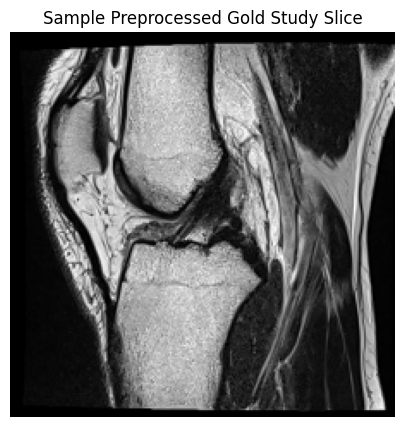

In [5]:
# Quick test on one gold-study series before full run.

sample_row = selected_series.iloc[0]
sample_study_id = sample_row["StudyInstanceUID"]
sample_series_id = sample_row["SeriesInstanceUID"]

sample_series_path = os.path.join(
    DATA_DIR,
    "train_series",
    sample_study_id,
    sample_series_id
)

sample_volume, sample_error = preprocess_series(sample_series_path, TARGET_SIZE)

print("Sample study:", sample_study_id)
print("Sample series:", sample_series_id)
print("Error:", sample_error)

if sample_volume is not None:
    print("Sample processed shape:", sample_volume.shape)
    print("Min:", sample_volume.min())
    print("Max:", sample_volume.max())
    print("NaN:", np.isnan(sample_volume).sum())

    middle = sample_volume.shape[0] // 2
    plt.figure(figsize=(5, 5))
    plt.imshow(sample_volume[middle], cmap="gray")
    plt.title("Sample Preprocessed Gold Study Slice")
    plt.axis("off")
    plt.show()

In [6]:
# Full preprocessing for all complete gold-labelled studies.
# This should be manageable because there are only 58 studies.

results = []
errors = []

for _, row in tqdm(selected_series.iterrows(), total=len(selected_series)):
    study_id = row["StudyInstanceUID"]
    series_id = row["SeriesInstanceUID"]

    series_path = os.path.join(
        DATA_DIR,
        "train_series",
        study_id,
        series_id
    )

    if not os.path.exists(series_path):
        errors.append({
            "StudyInstanceUID": study_id,
            "SeriesInstanceUID": series_id,
            "Error": "Series path does not exist"
        })
        continue

    processed, err = preprocess_series(series_path, TARGET_SIZE)

    if err is not None or processed is None:
        errors.append({
            "StudyInstanceUID": study_id,
            "SeriesInstanceUID": series_id,
            "Error": err if err is not None else "Unknown preprocessing error"
        })
        continue

    study_output_dir = os.path.join(OUTPUT_DIR, study_id)
    os.makedirs(study_output_dir, exist_ok=True)

    save_path = os.path.join(study_output_dir, series_id + ".npy")
    np.save(save_path, processed)

    results.append({
        "StudyInstanceUID": study_id,
        "SeriesInstanceUID": series_id,
        "Anatomical_Plane": row["Anatomical_Plane"],
        "Fluid_Sensitive": row["Fluid_Sensitive"],
        "Fat_Suppression": row["Fat_Suppression"],
        "File_Path": save_path,
        "Num_Slices": int(processed.shape[0]),
        "Height": int(processed.shape[1]),
        "Width": int(processed.shape[2]),
        "DType": str(processed.dtype)
    })

    del processed
    gc.collect()

metadata = pd.DataFrame(results)
error_df = pd.DataFrame(errors)

metadata_path = WORK_DIR + "/processed_metadata.csv"
errors_path = WORK_DIR + "/preprocessing_errors.csv"

metadata.to_csv(metadata_path, index=False)
error_df.to_csv(errors_path, index=False)

print("Saved:", metadata_path)
print("Saved:", errors_path)
print("Processed series:", len(metadata))
print("Errors:", len(error_df))
print("Processed gold studies:", metadata["StudyInstanceUID"].nunique() if len(metadata) else 0)

  0%|          | 0/336 [00:00<?, ?it/s]

Saved: /kaggle/working/processed_metadata.csv
Saved: /kaggle/working/preprocessing_errors.csv
Processed series: 336
Errors: 0
Processed gold studies: 58


In [7]:
# Final concise audit. Do not print all file paths.

processed_gold_ids = set(metadata["StudyInstanceUID"].unique()) if len(metadata) else set()
expected_gold_ids = set(gold_study_ids)
missing_gold_ids = sorted(expected_gold_ids - processed_gold_ids)

print("Expected gold studies:", len(expected_gold_ids))
print("Processed gold studies:", len(processed_gold_ids))
print("Missing gold studies:", len(missing_gold_ids))

if missing_gold_ids:
    print("First missing gold studies:", missing_gold_ids[:10])

print("Metadata summary:")
if len(metadata):
    print("Processed series:", len(metadata))
    print("Total processed slices:", int(metadata["Num_Slices"].sum()))
    print("Median slices per series:", float(metadata["Num_Slices"].median()))
    print("Series by anatomical plane:")
    print(metadata["Anatomical_Plane"].value_counts())

print("Error summary:")
if len(error_df):
    display(error_df.head(20))
else:
    print("No preprocessing errors.")

# For strict final pipeline, all 58 gold studies should be represented.
if missing_gold_ids:
    raise ValueError("Some complete gold-labelled studies were not processed. Review preprocessing_errors.csv.")

Expected gold studies: 58
Processed gold studies: 58
Missing gold studies: 0
Metadata summary:
Processed series: 336
Total processed slices: 10528
Median slices per series: 30.0
Series by anatomical plane:
Anatomical_Plane
Sagittal    136
Coronal     119
Axial        81
Name: count, dtype: int64
Error summary:
No preprocessing errors.


Sample file exists: True
Sample path: /kaggle/working/processed_data/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.10791858932231443712736629517371931282.npy
Sample shape: (36, 224, 224)
Sample dtype: float16
Min: 0.0
Max: 1.0
NaN: 0


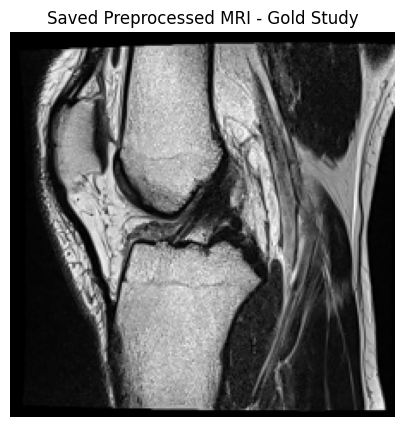

In [8]:
# Sanity check one saved .npy file.

if len(metadata) > 0:
    sample_path = metadata["File_Path"].iloc[0]
    sample = np.load(sample_path)

    print("Sample file exists:", os.path.exists(sample_path))
    print("Sample path:", sample_path)
    print("Sample shape:", sample.shape)
    print("Sample dtype:", sample.dtype)
    print("Min:", sample.min())
    print("Max:", sample.max())
    print("NaN:", np.isnan(sample).sum())

    middle = sample.shape[0] // 2
    plt.figure(figsize=(5, 5))
    plt.imshow(sample[middle], cmap="gray")
    plt.title("Saved Preprocessed MRI - Gold Study")
    plt.axis("off")
    plt.show()